### 로지스틱 회귀로 와인 분류하기

In [1]:
import pandas as pd

In [3]:
wine = pd.read_csv('data/wine.csv')
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [5]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [8]:
wine['class'].value_counts()

class
1.0    4898
0.0    1599
Name: count, dtype: int64

In [9]:
wine.shape

(6497, 4)

In [11]:
# 기본 통계량
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


#### Feature와 Target

In [25]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

#### Train과 Test

In [23]:
from sklearn.model_selection import train_test_split

In [26]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        data,
        target,
        test_size = 0.2,
        random_state = 42
    )

In [27]:
print('Train', train_input.shape)
print('Test', test_input.shape)

Train (5197, 3)
Test (1300, 3)


#### 로지스틱 회귀이므로 표준화하기

In [29]:
from sklearn.preprocessing import StandardScaler

In [31]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### 로지스틱 회귀 모델

In [32]:
from sklearn.linear_model import LogisticRegression

In [36]:
lr = LogisticRegression()
lr.fit(train_input, train_target)
print('Train: ', lr.score(train_input, train_target))
print('Test: ', lr.score(test_input, test_target))

Train:  0.7794881662497595
Test:  0.7761538461538462


In [38]:
# 가중치와 편차 구하기
print(lr.coef_, lr.intercept_)

[[ 0.4270427   0.35107217 -4.06298437]] [8.48363274]


#### Decision Tree를 이용한 모델의 생성

In [42]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
dt = DecisionTreeClassifier()
dt.fit(train_input, train_target)
print('Train: ', dt.score(train_input, train_target))
print('Test: ', dt.score(test_input, test_target))

Train:  0.996921300750433
Test:  0.8576923076923076


In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

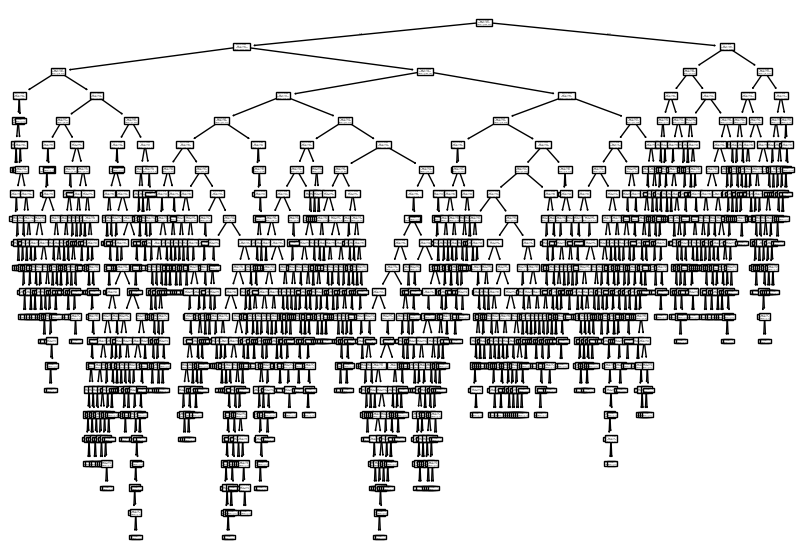

In [51]:
plt.figure(figsize=(10, 7))
plot_tree(dt)
plt.show()

In [48]:
# 맨 위의 단계를 root node라 하고 맨 마지막 단계는 leaf node라 한다.
# 시간이 많이 걸리고 복잡하다.

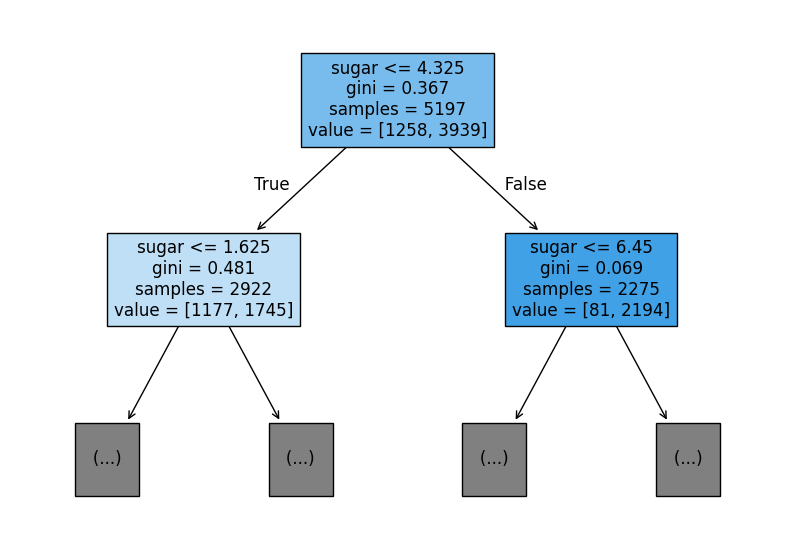

In [52]:
plt.figure(figsize=(10, 7))
plot_tree(
    dt,
    max_depth=1,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

- 가장 중요도 높은 Feature가 Sugar
- 양성(1)일수록 파란색으로 표시된다
- 루트노드에서 sugar <= 4.325이면 F(2275), 아니면 T(2922)
- gini: 판단기준, 이 모델 과정을 진행해야하는지를 판단, 불순도라고 함. 0에 가까울 수록 순수함
- 지니 불순도가 0일때 순수 노드라 한다.
- leaf node(마지막 노드)가 순수 노드인 것은 좋으나, 과대적합이 발생
- 따라서 적절한 max_depth를 찾는 것이 중요하다

#### 가지치기
- max_depth의 parameter 값을 조절
- Decision Tree의 과대적합을 막는다.
- 선형회귀처럼 규제를 사용할 수 없다.

In [59]:
dt = DecisionTreeClassifier(
    max_depth=8
)
dt.fit(train_input, train_target)
print('Train: ', dt.score(train_input, train_target))
print('Test: ', dt.score(test_input, test_target))

Train:  0.9005195304983644
Test:  0.8592307692307692


plt.figure(figsize=(20, 15))
plot_tree(
    dt,
    filled=True,
    max_depth=3,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

In [70]:
# 특성 중요도
dt.feature_importances_

array([0.17615651, 0.65463987, 0.16920363])

alcohol, sugar, ph 순으로 특성중요도가 출력되며 이중 sugar가 가장 중요한 요소로 작용한다는 것을 알 수 있다.

#### 최적화 시키기

In [72]:
dt = DecisionTreeClassifier(
    min_impurity_decrease=0.0005 # 노드를 분할하는 기준인 최소 불순도를 0.05%로 결정
)
dt.fit(train_input, train_target)
print('Train: ', dt.score(train_input, train_target))
print('Test: ', dt.score(test_input, test_target))

Train:  0.8874350586877044
Test:  0.8615384615384616


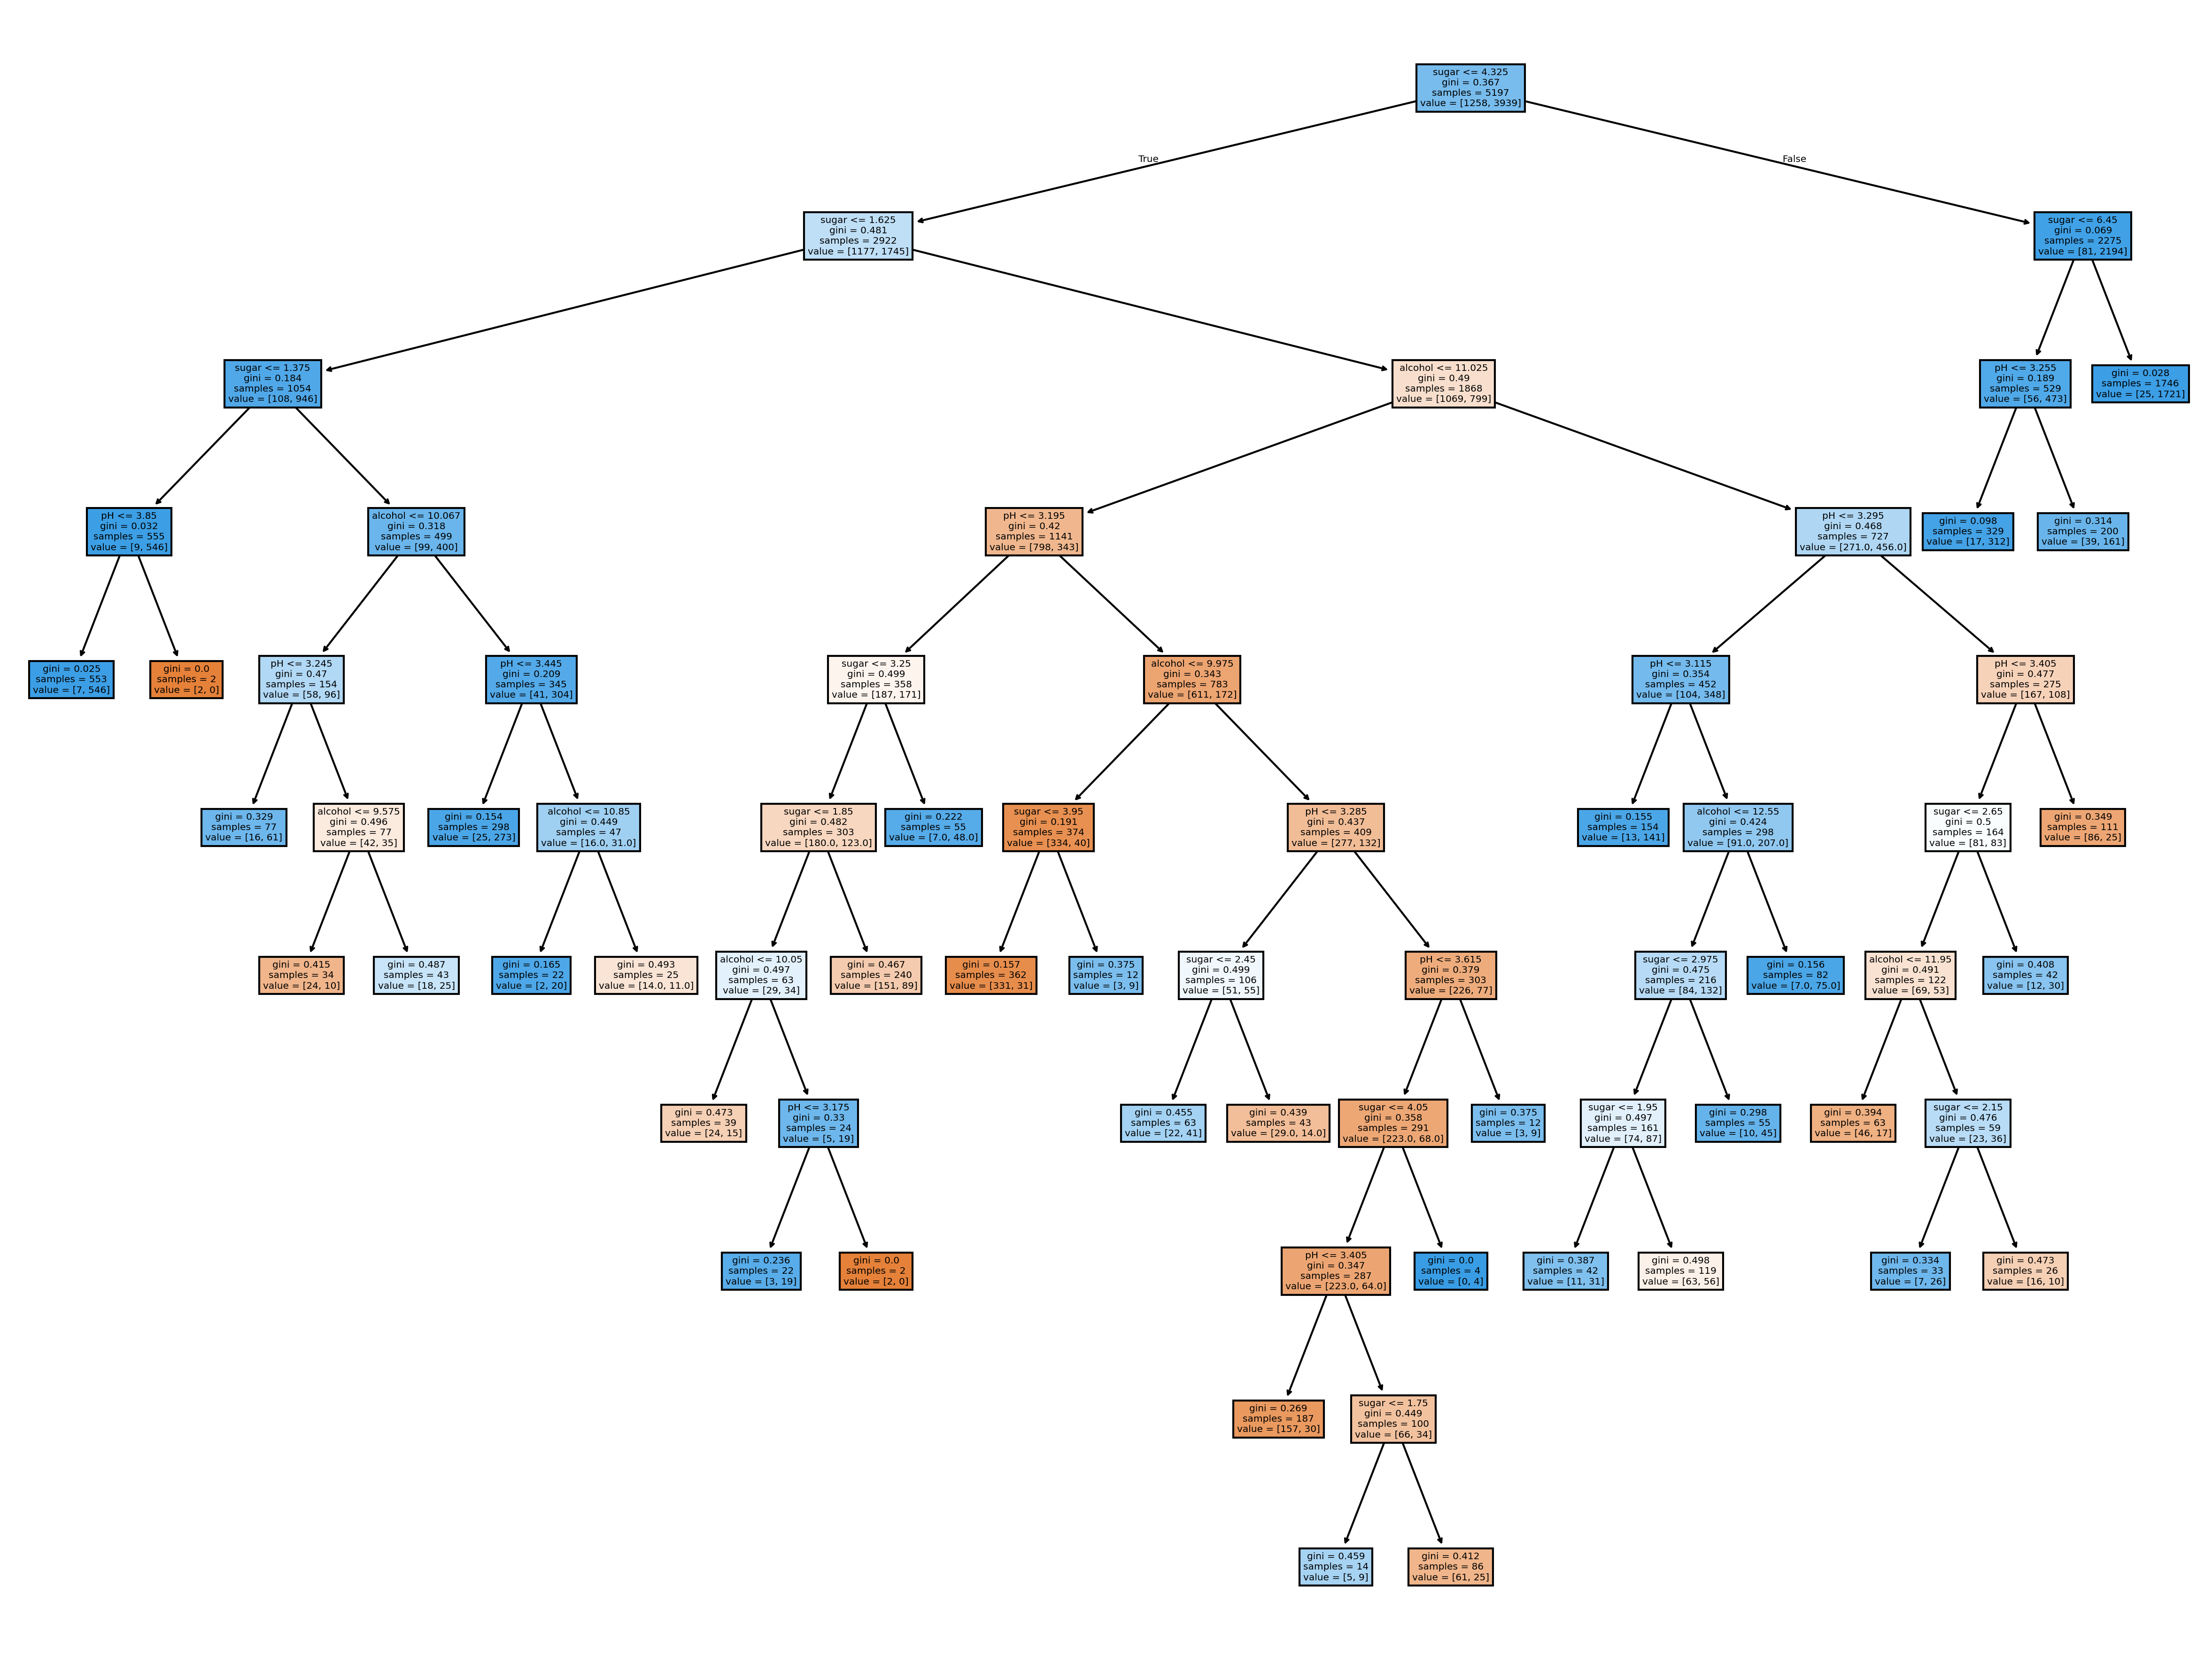

In [76]:
plt.figure(figsize=(20, 15), dpi=300)
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.savefig('data/wine.jpg')
plt.show()